In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ── Config ──
MODEL_SUBDIR = "Qwen/Qwen2.5-14B-Instruct"

USER = os.environ.get("USER", os.environ.get("USERNAME", ""))
BASE = f"/work/pi_dagarwal_umass_edu/project_4/file_storage/{USER}"

PIPELINE_ROOT = f"{BASE}/experiment_outputs"
EVAL_ROOT     = f"{BASE}/evaluation_outputs"
ENTITY_ROOT   = f"{BASE}/entity_extraction_output"
VIZ_ROOT      = "visualization_outputs"

VIZ_DIR = f"{VIZ_ROOT}/{MODEL_SUBDIR}/comparison"
os.makedirs(VIZ_DIR, exist_ok=True)

# Consistent colors across all series
COLORS = {
    "Replace All": "#1f77b4",
    "Replace One": "#ff7f0e",
    "Search":      "#2ca02c",
    "Agentic RAG": "#9467bd",
}

In [2]:
# ── Load evaluation outputs ──
eval_files = {
    "Replace All": f"{EVAL_ROOT}/{MODEL_SUBDIR}/local_replace_all_eval.json",
    "Replace One": f"{EVAL_ROOT}/{MODEL_SUBDIR}/local_replace_one_eval.json",
    "Search":      f"{EVAL_ROOT}/{MODEL_SUBDIR}/local_search_eval.json",
    "Agentic RAG": f"{EVAL_ROOT}/{MODEL_SUBDIR}/local_agentic_rag_eval.json",
}
eval_data = {}
for label, path in eval_files.items():
    with open(path, "r", encoding="utf-8") as f:
        eval_data[label] = json.load(f)

# ── Load entity extraction outputs ──
entity_files = {
    "Replace All": f"{ENTITY_ROOT}/{MODEL_SUBDIR}/local_replace_all_entity_results.json",
    "Replace One": f"{ENTITY_ROOT}/{MODEL_SUBDIR}/local_replace_one_entity_results.json",
    "Search":      f"{ENTITY_ROOT}/{MODEL_SUBDIR}/local_search_entity_results.json",
    "Agentic RAG": f"{ENTITY_ROOT}/{MODEL_SUBDIR}/local_agentic_rag_entity_results.json",
}
entity_data = {}
for label, path in entity_files.items():
    with open(path, "r", encoding="utf-8") as f:
        entity_data[label] = json.load(f)

# ── Load raw pipeline output (agentic only — needed for tool calls) ──
with open(f"{PIPELINE_ROOT}/{MODEL_SUBDIR}/local_agentic_rag.json", "r", encoding="utf-8") as f:
    agentic_pipeline_data = json.load(f)

for label in eval_data:
    print(f"{label}: {len(eval_data[label]['questions'])} questions in eval, "
          f"{len(entity_data[label]['questions'])} in entity")

Replace All: 400 questions in eval, 400 in entity
Replace One: 400 questions in eval, 400 in entity
Search: 400 questions in eval, 400 in entity
Agentic RAG: 400 questions in eval, 400 in entity


In [3]:
# ── Helpers ──

def is_collapsed(iteration_runs):
    """True if every run in the iteration has an identical canonical entity set."""
    sets = [frozenset(r["canonical_entities"]) for r in iteration_runs]
    return len(set(sets)) == 1

def mean_metric_per_round(experiment, metric_key):
    """Mean of metric_key across questions per iteration, from eval-style files."""
    max_iters = max(len(q["iterations"]) for q in experiment["questions"])
    round_means = []
    for iter_num in range(max_iters):
        vals = [
            q["iterations"][iter_num]["metrics"].get(metric_key, 0.0)
            for q in experiment["questions"]
            if iter_num < len(q["iterations"])
        ]
        round_means.append(np.mean(vals) if vals else 0.0)
    return round_means

def compute_collapse_metrics(experiment):
    start_collapsed, end_collapsed, pct_rounds = [], [], []
    for q in experiment["questions"]:
        iters = q["iterations"]
        if not iters:
            continue
        flags = [is_collapsed(it["runs"]) for it in iters]
        start_collapsed.append(1 if flags[0] else 0)
        end_collapsed.append(1 if flags[-1] else 0)
        pct_rounds.append(sum(flags) / len(flags) * 100)
    n = len(start_collapsed)
    return {
        "start_mean":  sum(start_collapsed) / n * 100,
        "end_mean":    sum(end_collapsed)   / n * 100,
        "end_std":     np.std([c * 100 for c in end_collapsed]),
        "rounds_mean": np.mean(pct_rounds),
        "rounds_std":  np.std(pct_rounds),
    }

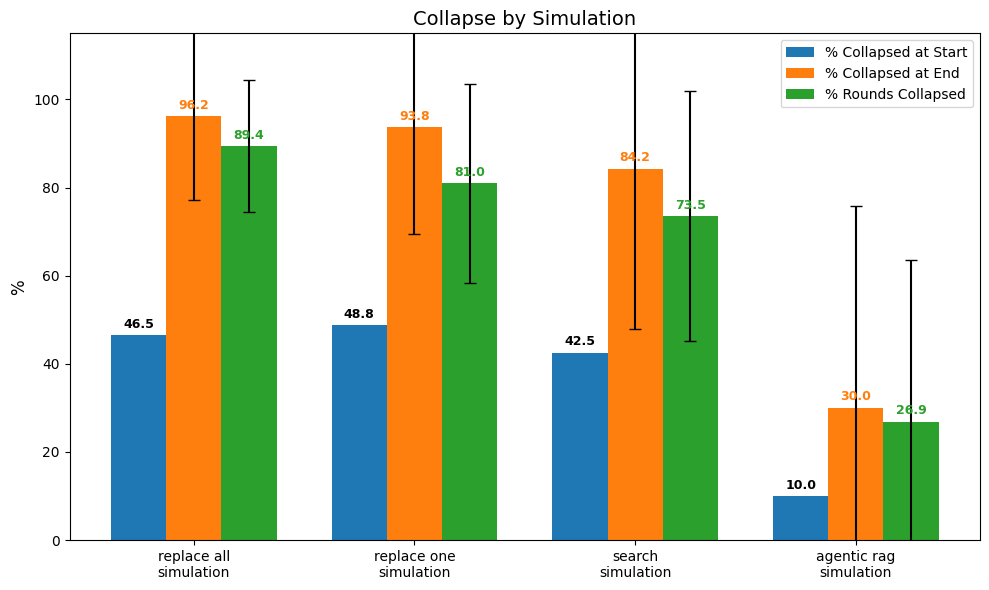

In [4]:
# ── Collapse by Simulation (bar chart) ──

metrics = {label: compute_collapse_metrics(exp) for label, exp in entity_data.items()}

simulations  = list(metrics.keys())
x            = np.arange(len(simulations))
width        = 0.25
start_means  = [metrics[s]["start_mean"]  for s in simulations]
end_means    = [metrics[s]["end_mean"]    for s in simulations]
end_stds     = [metrics[s]["end_std"]     for s in simulations]
rounds_means = [metrics[s]["rounds_mean"] for s in simulations]
rounds_stds  = [metrics[s]["rounds_std"]  for s in simulations]

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, start_means,  width, label="% Collapsed at Start", color="#1f77b4")
bars2 = ax.bar(x,         end_means,    width, yerr=end_stds,    capsize=4, label="% Collapsed at End",   color="#ff7f0e")
bars3 = ax.bar(x + width, rounds_means, width, yerr=rounds_stds, capsize=4, label="% Rounds Collapsed",   color="#2ca02c")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#ff7f0e")
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#2ca02c")

ax.set_ylabel("%", fontsize=12)
ax.set_title("Collapse by Simulation", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f"{s.lower()}\nsimulation" for s in simulations], fontsize=10)
ax.legend(loc="upper right")
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/collapse_by_simulation.png", dpi=150, bbox_inches="tight")
plt.show()

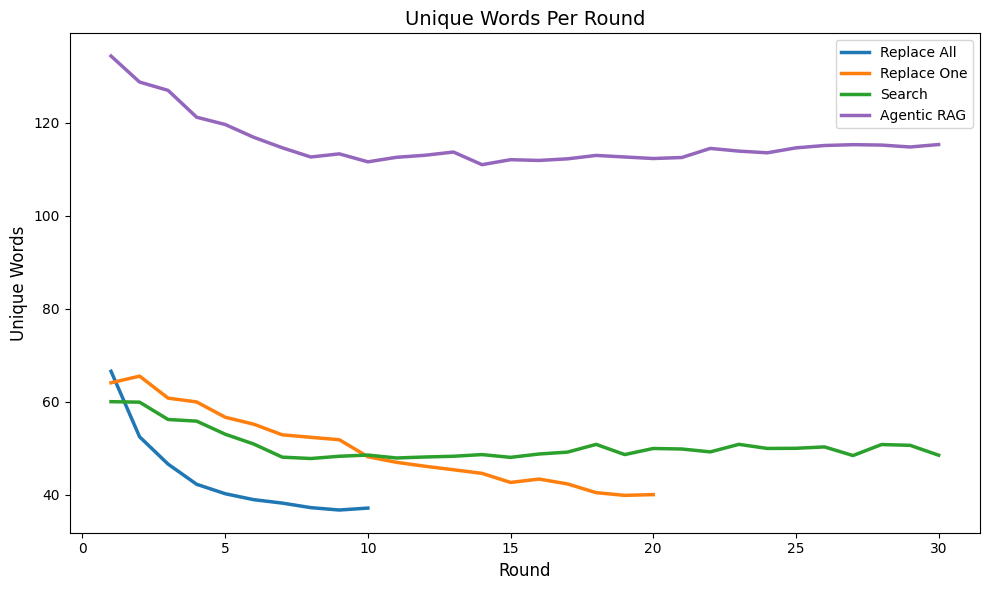

In [5]:
# ── Unique Words Per Round ──

fig, ax = plt.subplots(figsize=(10, 6))
for label, exp in eval_data.items():
    uw = mean_metric_per_round(exp, "unique_words")
    ax.plot(range(1, len(uw) + 1), uw, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Unique Words", fontsize=12)
ax.set_title("Unique Words Per Round", fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/unique_words_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

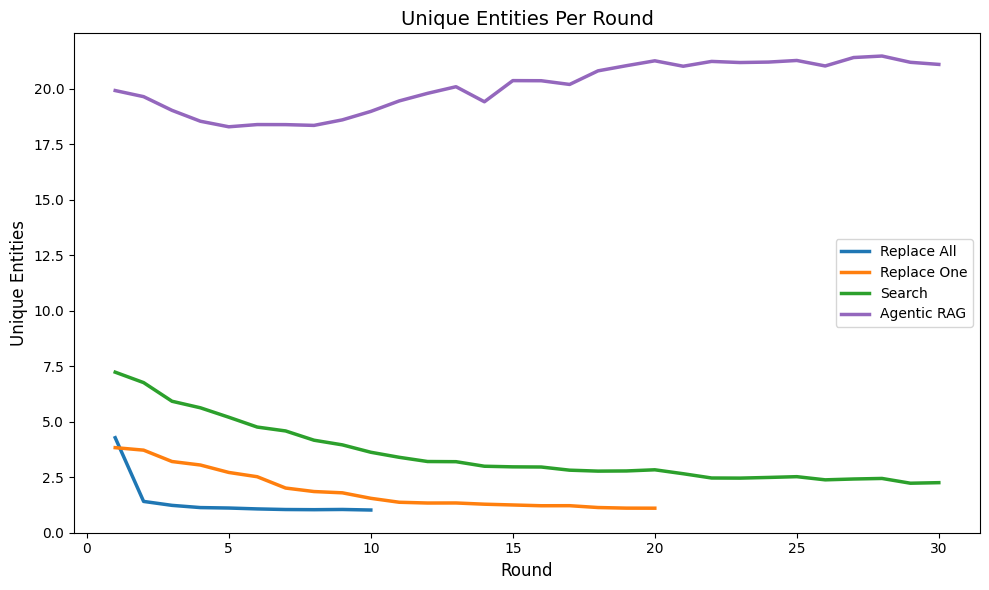

In [6]:
# ── Unique Entities Per Round ──

fig, ax = plt.subplots(figsize=(10, 6))
for label, exp in entity_data.items():
    agg = exp["aggregate_statistics"]["mean_unique_entities_per_round"]
    ax.plot(range(1, len(agg) + 1), agg, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Unique Entities", fontsize=12)
ax.set_title("Unique Entities Per Round", fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/unique_entities_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

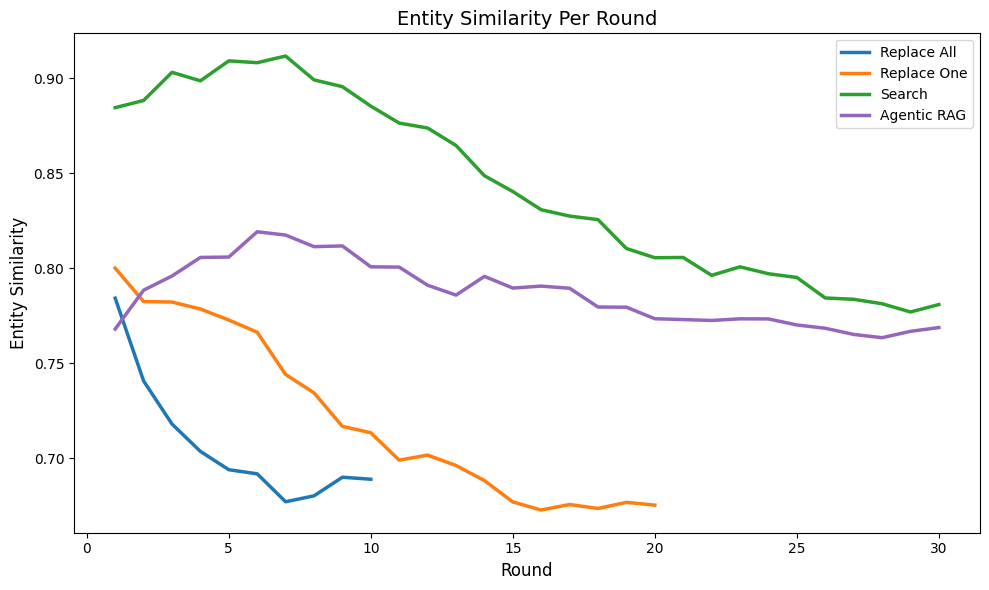

In [7]:
# ── Entity Similarity Per Round ──

fig, ax = plt.subplots(figsize=(10, 6))
for label, exp in entity_data.items():
    agg = exp["aggregate_statistics"]["mean_entity_similarity_per_round"]
    ax.plot(range(1, len(agg) + 1), agg, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Entity Similarity", fontsize=12)
ax.set_title("Entity Similarity Per Round", fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/entity_similarity_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

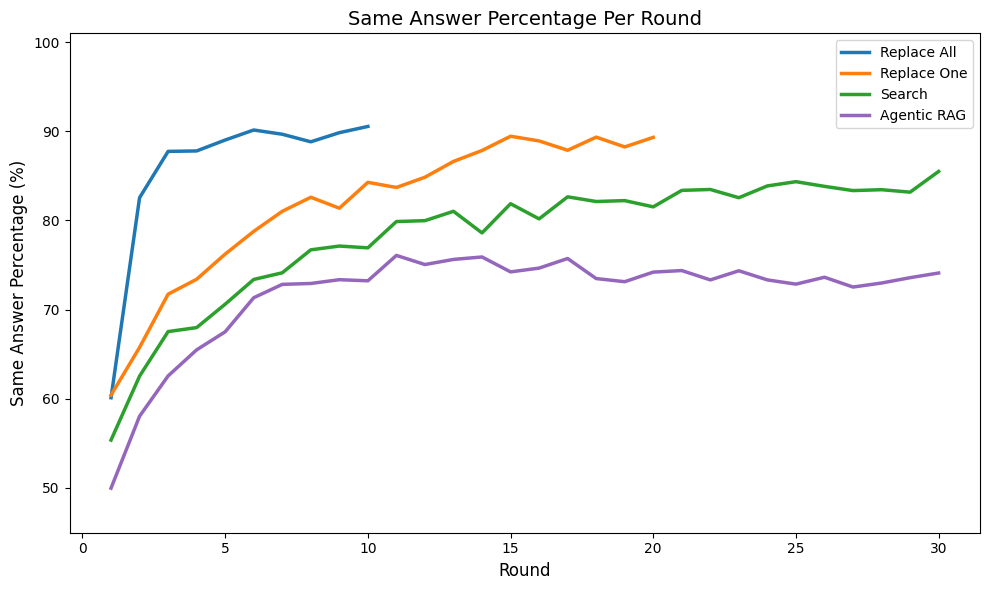

In [8]:
# ── Same Answer Percentage Per Round ──

fig, ax = plt.subplots(figsize=(10, 6))
all_vals = []
for label, exp in eval_data.items():
    sap = mean_metric_per_round(exp, "same_answer_percentage")
    all_vals.extend(sap)
    ax.plot(range(1, len(sap) + 1), sap, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Same Answer Percentage (%)", fontsize=12)
ax.set_title("Same Answer Percentage Per Round", fontsize=14)
ax.set_ylim(max(0, min(all_vals) - 5), 101)
ax.legend()

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/same_answer_percentage_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

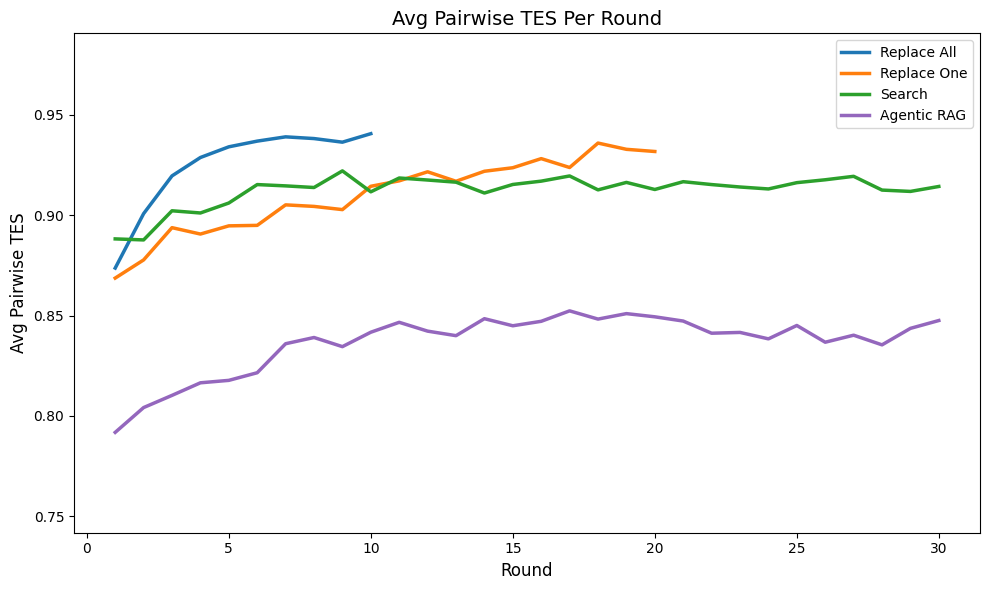

In [9]:
# ── Avg Pairwise TES Per Round ──

fig, ax = plt.subplots(figsize=(10, 6))
all_vals = []
for label, exp in eval_data.items():
    tes = mean_metric_per_round(exp, "avg_pairwise_tes")
    all_vals.extend(tes)
    ax.plot(range(1, len(tes) + 1), tes, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Avg Pairwise TES", fontsize=12)
ax.set_title("Avg Pairwise TES Per Round", fontsize=14)
ax.set_ylim(max(0, min(all_vals) - 0.05), min(1.0, max(all_vals) + 0.05))
ax.legend()

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/avg_pairwise_tes_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

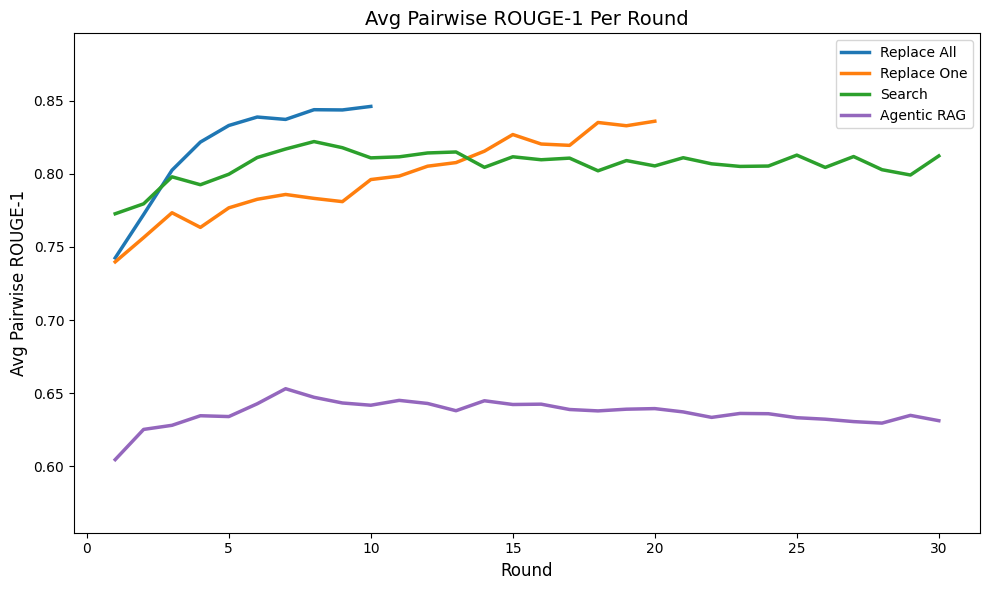

In [10]:
# ── Avg Pairwise ROUGE-1 Per Round ──

fig, ax = plt.subplots(figsize=(10, 6))
all_vals = []
for label, exp in eval_data.items():
    r1 = mean_metric_per_round(exp, "avg_pairwise_rouge1")
    all_vals.extend(r1)
    ax.plot(range(1, len(r1) + 1), r1, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Avg Pairwise ROUGE-1", fontsize=12)
ax.set_title("Avg Pairwise ROUGE-1 Per Round", fontsize=14)
ax.set_ylim(max(0, min(all_vals) - 0.05), min(1.0, max(all_vals) + 0.05))
ax.legend()

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/avg_pairwise_rouge1_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

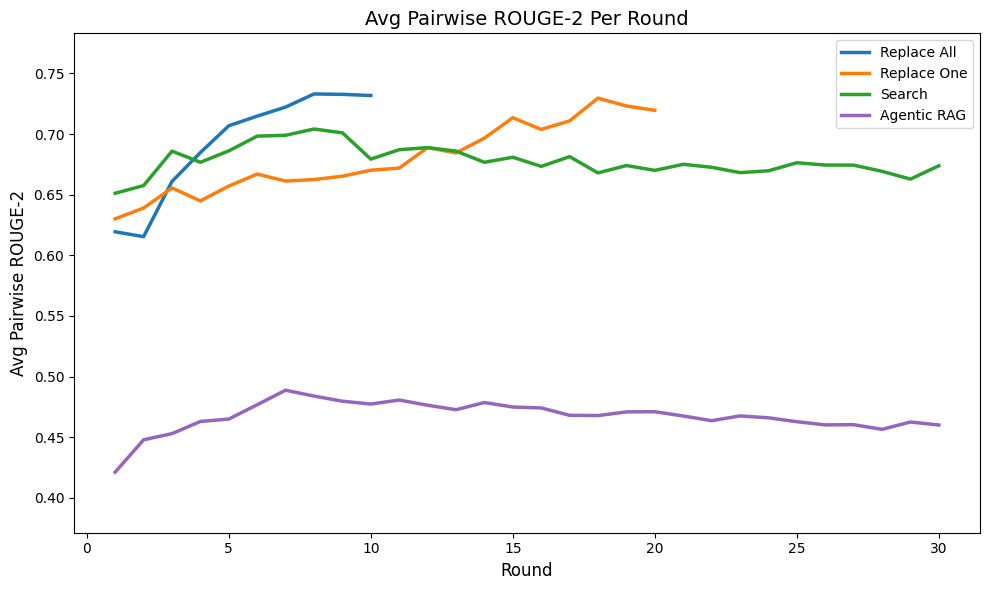

In [11]:
# ── Avg Pairwise ROUGE-2 Per Round ──

fig, ax = plt.subplots(figsize=(10, 6))
all_vals = []
for label, exp in eval_data.items():
    r2 = mean_metric_per_round(exp, "avg_pairwise_rouge2")
    all_vals.extend(r2)
    ax.plot(range(1, len(r2) + 1), r2, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Avg Pairwise ROUGE-2", fontsize=12)
ax.set_title("Avg Pairwise ROUGE-2 Per Round", fontsize=14)
ax.set_ylim(max(0, min(all_vals) - 0.05), min(1.0, max(all_vals) + 0.05))
ax.legend()

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/avg_pairwise_rouge2_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

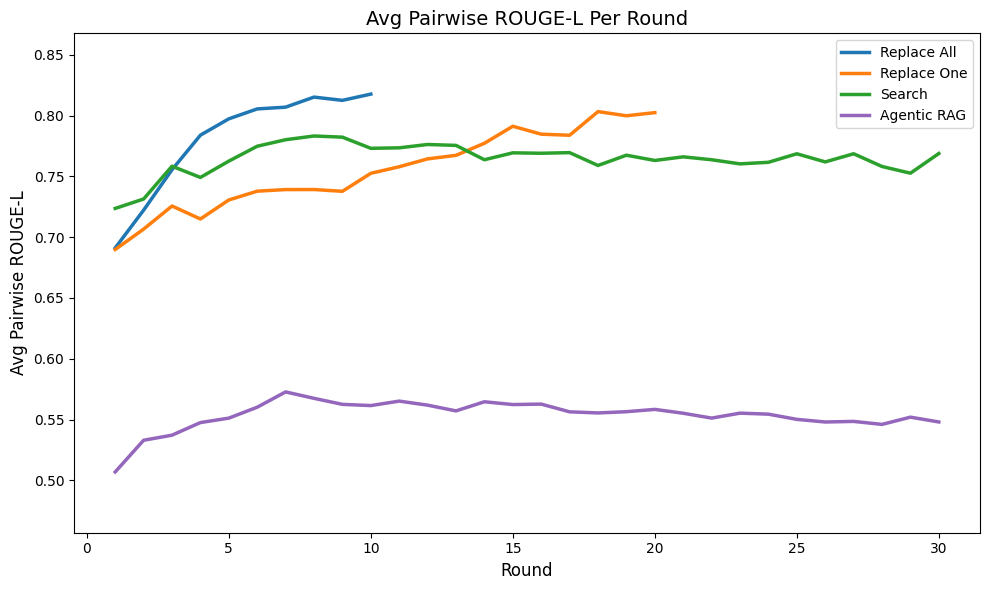

In [12]:
# ── Avg Pairwise ROUGE-L Per Round ──

fig, ax = plt.subplots(figsize=(10, 6))
all_vals = []
for label, exp in eval_data.items():
    rl = mean_metric_per_round(exp, "avg_pairwise_rougeL")
    all_vals.extend(rl)
    ax.plot(range(1, len(rl) + 1), rl, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Avg Pairwise ROUGE-L", fontsize=12)
ax.set_title("Avg Pairwise ROUGE-L Per Round", fontsize=14)
ax.set_ylim(max(0, min(all_vals) - 0.05), min(1.0, max(all_vals) + 0.05))
ax.legend()

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/avg_pairwise_rougeL_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

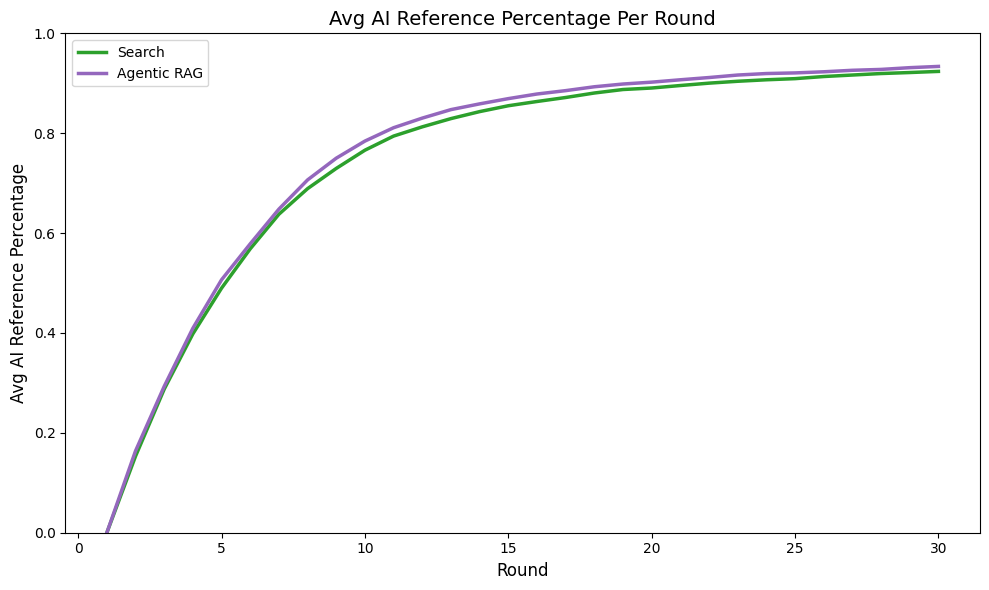

In [13]:
# ── Avg AI Reference Percentage Per Round — Search & Agentic RAG only ──
# Only retrieval-based variants accumulate AI-generated references across rounds.

fig, ax = plt.subplots(figsize=(10, 6))
all_vals = []
for label, exp in eval_data.items():
    if label not in ("Search", "Agentic RAG"):
        continue
    vals = mean_metric_per_round(exp, "ai_reference_percentage")
    all_vals.extend(vals)
    ax.plot(range(1, len(vals) + 1), vals, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Avg AI Reference Percentage", fontsize=12)
ax.set_title("Avg AI Reference Percentage Per Round", fontsize=14)
ax.set_ylim(max(0, min(all_vals) - 0.05), 1.0)
ax.legend()

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/avg_ai_reference_percentage_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

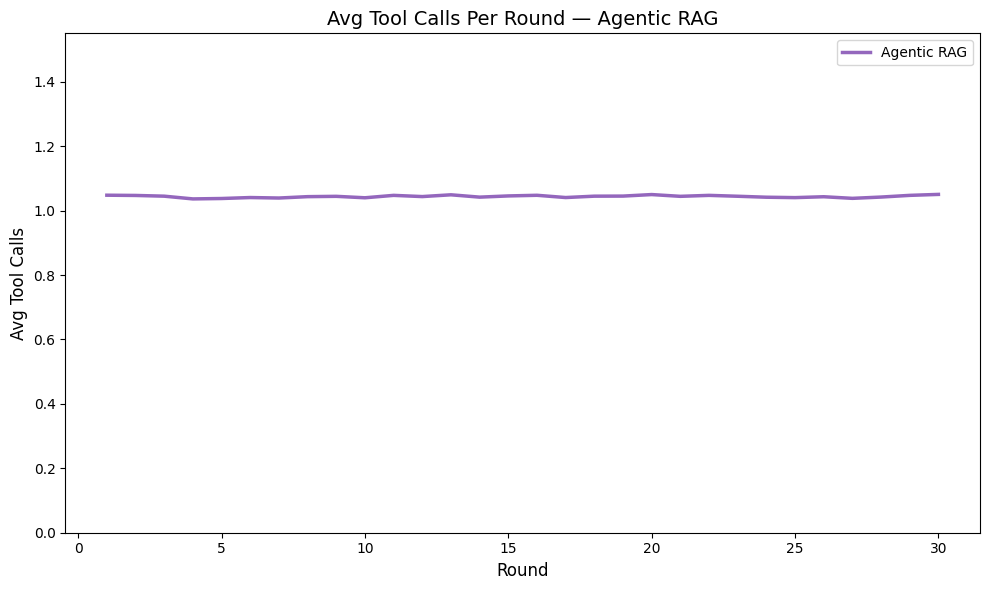

In [14]:
# ── Avg Tool Calls Per Round — Agentic RAG only ──
# tool_calls_used is only available in the raw agentic pipeline output.

def mean_tool_calls_per_round(pipeline_experiment):
    max_iters = max(len(q["iterations"]) for q in pipeline_experiment["questions"])
    round_means = []
    for iter_num in range(max_iters):
        counts = [
            run["tool_calls_used"]
            for q in pipeline_experiment["questions"]
            if iter_num < len(q["iterations"])
            for run in q["iterations"][iter_num]["runs"]
            if "tool_calls_used" in run
        ]
        round_means.append(np.mean(counts) if counts else 0.0)
    return round_means

tc = mean_tool_calls_per_round(agentic_pipeline_data)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(tc) + 1), tc, linewidth=2.5, label="Agentic RAG", color=COLORS["Agentic RAG"])
ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Avg Tool Calls", fontsize=12)
ax.set_title("Avg Tool Calls Per Round — Agentic RAG", fontsize=14)
ax.set_ylim(0, max(tc) + 0.5)
ax.legend()

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/avg_tool_calls_per_round.png", dpi=150, bbox_inches="tight")
plt.show()